In [1]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import classification_report

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as snsa
from sklearn.metrics import classification_report

from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

from sklearn.model_selection import KFold, cross_val_score,cross_validate
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel

from boruta import BorutaPy

In [127]:
# !pip install openpyxl

In [128]:
# path = "C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel("app_data.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [129]:
df["Diagnosis"].value_counts()

Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64

In [130]:
df.shape

(782, 58)

In [131]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [132]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


Diagnosis
appendicitis       463
no appendicitis    317
NaN                  2
Name: count, dtype: int64

In [133]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64

In [134]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [135]:
# correlation of different columns with each other
# df.corr()

In [136]:
#  correlation of our output column with other columns
# df.corr()['Diagnosis']

In [137]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [138]:
df["Appendix_on_US"] = (df["Appendix_on_US"]=='yes').astype(int)

In [139]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [140]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [141]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Severity","Length_of_Stay"]

In [142]:
df["Management"] = (df["Management"]!= 'conservative').astype(int)

In [143]:
df["Management"].value_counts()

Management
0    483
1    297
Name: count, dtype: int64

In [144]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [145]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 781
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Management                        780 non-null    int32  
 6   Diagnosis                         780 non-null    int32  
 7   Alvarado_Score                    730 non-null    float64
 8   Paedriatic_Appendicitis_Score     730 non-null    float64
 9   Appendix_on_US                    780 non-null    int32  
 10  Appendix_Diameter                 498 non-null    float64
 11  Migratory_Pain                    773 non-null    object 
 12  Lower_Right_A

In [146]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 781
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Management                        780 non-null    int32  
 6   Diagnosis                         780 non-null    int32  
 7   Alvarado_Score                    730 non-null    float64
 8   Paedriatic_Appendicitis_Score     730 non-null    float64
 9   Appendix_on_US                    780 non-null    int32  
 10  Appendix_Diameter                 498 non-null    float64
 11  Migratory_Pain                    773 non-null    object 
 12  Lower_Right_A

<h2>Selecting only those rows which have no nan values : </h2>

In [148]:
df2 = df.dropna().copy()

In [149]:
df2

,Age,BMI,Sex,Height,Weight,Management,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,0,1,4.0,3.0,1,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,0,1,5.0,6.0,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,0,7.0,6.0,1,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,0,1,4.0,4.0,1,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,0,1,8.0,9.0,1,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,1,9.0,6.0,1,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,1,6.0,4.0,1,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,1,5.0,4.0,1,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,1,9.0,7.0,1,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [150]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Management', 'Diagnosis',
       'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US',
       'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count', 'Hemoglobin',
       'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign',
       'Ipsilateral_Rebound_Tenderness', 'Free_Fluids'],
      dtype='object')

In [151]:
df2["WBC_in_Urine"].value_counts()

WBC_in_Urine
no     206
+       22
++       7
+++      3
Name: count, dtype: int64

In [152]:
df2["Sex"].value_counts()

Sex
male      124
female    114
Name: count, dtype: int64

In [153]:
df2["Diagnosis"].value_counts()

Diagnosis
1    157
0     81
Name: count, dtype: int64

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 781
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Management                        780 non-null    int32  
 6   Diagnosis                         780 non-null    int32  
 7   Alvarado_Score                    730 non-null    float64
 8   Paedriatic_Appendicitis_Score     730 non-null    float64
 9   Appendix_on_US                    780 non-null    int32  
 10  Appendix_Diameter                 498 non-null    float64
 11  Migratory_Pain                    773 non-null    object 
 12  Lower_Right_A

In [155]:
df2["Sex"].value_counts()

Sex
male      124
female    114
Name: count, dtype: int64

In [156]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [157]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 781
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Management                        780 non-null    int32  
 6   Diagnosis                         780 non-null    int32  
 7   Alvarado_Score                    730 non-null    float64
 8   Paedriatic_Appendicitis_Score     730 non-null    float64
 9   Appendix_on_US                    780 non-null    int32  
 10  Appendix_Diameter                 498 non-null    float64
 11  Migratory_Pain                    773 non-null    object 
 12  Lower_Right_A

In [159]:
df2["Lower_Right_Abd_Pain"].value_counts()

Lower_Right_Abd_Pain
yes    228
no      10
Name: count, dtype: int64

In [160]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

Lower_Right_Abd_Pain
1    228
0     10
Name: count, dtype: int64

In [161]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

Contralateral_Rebound_Tenderness
no     149
yes     89
Name: count, dtype: int64

In [162]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

Contralateral_Rebound_Tenderness
0    149
1     89
Name: count, dtype: int64

In [163]:
df2["Coughing_Pain"].value_counts(dropna = False)

Coughing_Pain
no     163
yes     75
Name: count, dtype: int64

In [164]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

Coughing_Pain
0    163
1     75
Name: count, dtype: int64

In [165]:
df2["Nausea"].value_counts(dropna = False)

Nausea
yes    132
no     106
Name: count, dtype: int64

In [166]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

Nausea
1    132
0    106
Name: count, dtype: int64

In [167]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

Loss_of_Appetite
yes    121
no     117
Name: count, dtype: int64

In [168]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

Loss_of_Appetite
1    121
0    117
Name: count, dtype: int64

In [169]:
df2["Neutrophilia"].value_counts(dropna = False)

Neutrophilia
no     138
yes    100
Name: count, dtype: int64

In [170]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

Neutrophilia
0    138
1    100
Name: count, dtype: int64

In [171]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

Ketones_in_Urine
no     148
+++     47
+       29
++      14
Name: count, dtype: int64

In [172]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

Ketones_in_Urine
0.0    148
3.0     47
1.0     29
2.0     14
Name: count, dtype: int64

In [173]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, 0 to 780
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Management                        238 non-null    int32  
 6   Diagnosis                         238 non-null    int32  
 7   Alvarado_Score                    238 non-null    float64
 8   Paedriatic_Appendicitis_Score     238 non-null    float64
 9   Appendix_on_US                    238 non-null    int32  
 10  Appendix_Diameter                 238 non-null    float64
 11  Migratory_Pain                    238 non-null    int32  
 12  Lower_Right_A

In [174]:
df2["RBC_in_Urine"].value_counts(dropna = False)

RBC_in_Urine
no     190
+       37
+++      7
++       4
Name: count, dtype: int64

In [175]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

RBC_in_Urine
0.0    190
1.0     37
3.0      7
2.0      4
Name: count, dtype: int64

In [176]:
df2["WBC_in_Urine"].value_counts(dropna= False)

WBC_in_Urine
no     206
+       22
++       7
+++      3
Name: count, dtype: int64

In [177]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

WBC_in_Urine
0.0    206
1.0     22
2.0      7
3.0      3
Name: count, dtype: int64

In [178]:
df2["Dysuria"].value_counts(dropna= False)

Dysuria
no     227
yes     11
Name: count, dtype: int64

In [179]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

Dysuria
0    227
1     11
Name: count, dtype: int64

In [180]:
df2["Stool"].value_counts()
#will do one hot encoding here

Stool
normal          174
diarrhea         37
constipation     27
Name: count, dtype: int64

In [181]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

Stool
1.0    174
2.0     37
0.0     27
Name: count, dtype: int64

In [182]:
df2["Peritonitis"].value_counts()

Peritonitis
no             189
local           43
generalized      6
Name: count, dtype: int64

In [183]:
enc = OrdinalEncoder(categories=[['no','local','generalized']])
enc.fit([['no'], ['local'], ['generalized']])                                 
df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
df2["Peritonitis"].value_counts(dropna = False)

Peritonitis
0.0    189
1.0     43
2.0      6
Name: count, dtype: int64

In [184]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.16187422499642207

In [185]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis"] = (df2["Peritonitis"]!=0).astype(int)

In [186]:
#dropping the Peritonitis Columns
# df2.drop(["Peritonitis"],axis=1, inplace =True)

In [187]:
# df2["Diagnosis"].corr(df2["Peritonitis_binary"])

In [188]:
df2["Psoas_Sign"].value_counts()

Psoas_Sign
no     160
yes     78
Name: count, dtype: int64

In [189]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [190]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

Ipsilateral_Rebound_Tenderness
no     226
yes     12
Name: count, dtype: int64

In [191]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [192]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, 0 to 780
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Management                        238 non-null    int32  
 6   Diagnosis                         238 non-null    int32  
 7   Alvarado_Score                    238 non-null    float64
 8   Paedriatic_Appendicitis_Score     238 non-null    float64
 9   Appendix_on_US                    238 non-null    int32  
 10  Appendix_Diameter                 238 non-null    float64
 11  Migratory_Pain                    238 non-null    int32  
 12  Lower_Right_A

In [193]:
# df2.corr()["Diagnosis"]

In [194]:
# plt.figure(figsize=(30,30))
# sns.heatmap(df2.corr())

In [195]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [196]:
df2["Diagnosis"].value_counts()

Diagnosis
1    157
0     81
Name: count, dtype: int64

In [197]:
df2 = df2[df2["Diagnosis"]==1]

In [198]:
df2.shape

(157, 35)

In [199]:
y = df2.loc[:,"Management"]
print(y.value_counts())
X = df2.loc[:,df2.columns!='Management']
X.shape

Management
0    112
1     45
Name: count, dtype: int64


(157, 34)

In [200]:
from sklearn.model_selection import train_test_split

In [201]:
x_train, x_test , y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [202]:
x_train.shape

(125, 34)

In [203]:
y_train.shape

(125,)

In [204]:
# Classifiers for selecting best Feature selection technique

# k nearest neighbors
KNN = KNeighborsClassifier(
    n_neighbors=5,      # Number of neighbors (common values: integers like 3, 5, 7)
    weights='uniform',  # Weight function used in prediction ('uniform' or 'distance')
    algorithm='auto',   # Algorithm used to compute nearest neighbors ('auto', 'ball_tree', 'kd_tree', 'brute')
    leaf_size=30,       # Leaf size passed to BallTree or KDTree (common values: integers like 10, 30, 50)
    p=2,                # Power parameter for the Minkowski metric (common values: 1 for Manhattan distance, 2 for Euclidean distance)
    metric='minkowski', # Distance metric for KNN ('euclidean', 'manhattan', 'chebyshev', 'minkowski')
    metric_params=None, # Additional keyword arguments for the metric function
    n_jobs=None         # Number of parallel jobs to run for neighbors search (-1 to use all processors)
)

# gaussian naive bayes
GNB = GaussianNB()

# multinomial naive bayes
MNB = MultinomialNB(alpha=1.0)  # Alpha is the smoothing parameter (common values: floats like 1.0, 0.1, 0.01)

# bernoulli naive bayes
BNB = BernoulliNB(alpha=1.0, binarize=0.0)  # Alpha is the smoothing parameter, binarize is the threshold for binarizing features

# logistic regression
LOGREG = LogisticRegression(
    penalty='l2',   # Type of regularization (default='l2')
    C=1.0,          # Inverse of regularization strength (default=1.0)
    solver='lbfgs', # Optimization algorithm (default='lbfgs')
    max_iter=1000   # Maximum number of iterations (default=100)
)

# support vector machines
SVM = SVC(
        kernel='rbf',   # Kernel type ('linear', 'poly', 'rbf', 'sigmoid', 'precomputed')
        C=1.0,          # Penalty parameter C of the error term
        gamma='scale',  # Kernel coefficient for 'rbf', 'poly', and 'sigmoid' kernels
        degree=3,       # Degree of the polynomial kernel function ('poly' kernel only)
        coef0=0.0       # Independent term in the 'poly' and 'sigmoid' kernels
)

# decision trees
DT = DecisionTreeClassifier(
        criterion='gini',     # Split criterion ('gini' or 'entropy')
        max_depth=None,       # Maximum depth of the tree
        min_samples_split=2,  # Minimum number of samples required to split an internal node
        min_samples_leaf=1,   # Minimum number of samples required to be at a leaf node
        max_features=None,    # Number of features to consider when looking for the best split
        random_state=42       # Random state for reproducibility
)


In [205]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0000 ± 0.0000
Score_time - Mean: 0.0330 ± 0.0031
Test_accuracy - Mean: 0.71 ± 0.07
Test_f1 - Mean: 0.28 ± 0.18
Test_roc_auc - Mean: 0.62 ± 0.08
Test_average_precision - Mean: 0.43 ± 0.09
Test_precision - Mean: 0.45 ± 0.28
Test_recall - Mean: 0.20 ± 0.13
AUPR: 0.41 ± 0.15


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0574 ± 0.0090
Score_time - Mean: 0.0053 ± 0.0014
Test_accuracy - Mean: 0.83 ± 0.07
Test_f1 - Mean: 0.70 ± 0.09
Test_roc_auc - Mean: 0.87 ± 0.06
Test_average_precision - Mean: 0.82 ± 0.07
Test_precision - Mean: 0.75 ± 0.13
Test_recall - Mean: 0.67 ± 0.12
AUPR: 0.81 ± 0.07
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0002 ± 0.0004
Score_time - Mean: 0.0052 ± 0.0012
Test_accuracy - Mean: 0.79 ± 0.08
Test_f1 - Mean: 0.65 ± 0.09
Test_roc_auc - Mean: 0.81 ± 0.09
Test_average_precision - Mean: 0.75 ± 0.04
Test_precision - Mean: 0.66 ± 0.14
Test_recall - Mean: 0.65 ± 0.06
AUPR: 0.74 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

## APPLYING VARIOUS FEATURE SELECTION AND EXTRACTION TECHNIQUES:

## Applying PCA (feature extraction) for dimensionality reduction:

In [206]:
#Applying PCA (feature extraction) for dimensionality reduction:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
x_reduced = pca.fit_transform(X)

In [207]:
print("The shize of the dataset is :(excluding the diagnosis column)",x_reduced.shape)

The shize of the dataset is :(excluding the diagnosis column) (157, 3)


In [208]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_reduced
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0006 ± 0.0005
Score_time - Mean: 0.0066 ± 0.0009
Test_accuracy - Mean: 0.68 ± 0.06
Test_f1 - Mean: 0.22 ± 0.09
Test_roc_auc - Mean: 0.53 ± 0.10
Test_average_precision - Mean: 0.34 ± 0.08
Test_precision - Mean: 0.37 ± 0.16
Test_recall - Mean: 0.16 ± 0.06
AUPR: 0.36 ± 0.11
------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0016 ± 0.0005
Score_time - Mean: 0.0049 ± 0.0008
Test_accuracy - Mean: 0.75 ± 0.06
Test_f1 - Mean: 0.37 ± 0.14
Test_roc_auc - Mean: 0.67 ± 0.09
Test_average_precision - Mean: 0.53 ± 0.12
Test_precision - Mean: 0.70 ± 0.27
Test_recall - Mean: 0.25 ± 0.10
AUPR: 0.50 ± 0.14
------------------------------------------------------------------------------------------------------




Classifier: Gaus

## Applyinng Fisher's Score for feature selection:

In [209]:
# Boosting Classifiers
# random forest
RF = RandomForestClassifier(
    n_estimators=100,    # Number of trees in the forest
    criterion='gini',    # Split criterion ('gini' or 'entropy')
    max_depth=None,      # Maximum depth of the tree
    min_samples_split=2, # Minimum number of samples required to split an internal node
    min_samples_leaf=1,  # Minimum number of samples required to be at a leaf node
#     max_features='auto', # Number of features to consider when looking for the best split
    random_state=42,     # Random state for reproducibility
    n_jobs=-1            # Number of jobs to run in parallel (-1 means using all processors)
)

# gradient boosting machine (GBM)
gbm_model = GradientBoostingClassifier(
    learning_rate=0.1,      # Learning rate or step size at which the model is updated. Typical values: [0.01, 0.05, 0.1].
    n_estimators=100,       # Number of boosting rounds (trees) to be used in the model. Typical values: [100, 200, 300].
    max_depth=6,            # Maximum depth of each tree. A higher value can lead to overfitting. Typical values: [3, 4, 5, 6].
    min_samples_split=2,    # Minimum number of samples required to split an internal node. Typical values: [2, 5, 10].
    min_samples_leaf=1,     # Minimum number of samples required to be at a leaf node. Typical values: [1, 2, 4].
    subsample=1.0,          # Subsample ratio of the training instance. Randomly selects a fraction of the data to grow trees. Typical values: [0.7, 0.8, 0.9].
    max_features=None,      # Number of features to consider when looking for the best split. Typical values: [None, 'sqrt', 'log2'].
    max_leaf_nodes=None,    # Maximum number of leaves in each tree. Typical values: [None, 10, 50, 100].
    random_state=42         # Seed for random number generator for reproducibility.
)


# light gradient boosting (lGBM)
LGBM = LGBMClassifier(verbose=-1)
    #learning_rate=0.1,      # Learning rate or step size at which the model is updated. Typical values: [0.01, 0.05, 0.1].
    #n_estimators=200,       # Number of boosting rounds (trees) to be used in the model. Typical values: [100, 200, 300].
    #max_depth=None,          # Maximum depth of each tree. A higher value can lead to overfitting. Typical values: [3, 4, 5, 6].
    #verbose=-1)

LGBM2 = LGBMClassifier(
    learning_rate=0.5,      # Learning rate or step size at which the model is updated. Typical values: [0.01, 0.05, 0.1].
    n_estimators=200,       # Number of boosting rounds (trees) to be used in the model. Typical values: [100, 200, 300].
    max_depth=None,          # Maximum depth of each tree. A higher value can lead to overfitting. Typical values: [3, 4, 5, 6].
    verbose=-1)
# xtreme gradient boosting (XGBoost)
XGB = XGBClassifier(objective='binary:logistic')

# categorical boosting (CatBoost)
CATBOOST = CatBoostClassifier(
    iterations=1500,          # Number of boosting iterations
    learning_rate=0.1,        # Learning rate for gradient boosting
    depth=6,                  # Depth of the trees
    loss_function='Logloss',  # Loss function to optimize
    eval_metric='Accuracy',   # Metric for evaluation
    random_seed=42)           # Random seed for reproducibility

# adaptive boosting (AdaBoost)
base_esti = LGBM # set to anything, tree based / normals / gbms

ADABOOST = AdaBoostClassifier(
    estimator=base_esti,  # Base estimator to use for boosting
    n_estimators=200,               # Number of weak learners to train iteratively
    learning_rate=0.5,             # Learning rate (shrinks the contribution of each classifier)
    algorithm='SAMME',           # AdaBoost algorithm ('SAMME' or 'SAMME.R')
    random_state=42)               # Random state for reproducibility

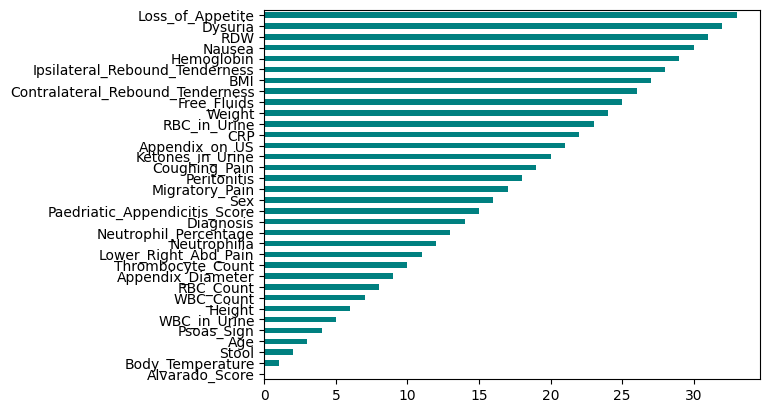

In [210]:
# pip install skfeature-chappers
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(X),np.array(y))
feat_importance = pd.Series(ranks, X.columns[0:len(X.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks>5]

In [216]:
x_fs= X.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_fs.columns)

The features retained after using this techniques are :
Index(['CRP', 'Body_Temperature', 'Alvarado_Score', 'Ketones_in_Urine',
       'Nausea', 'Loss_of_Appetite', 'Hemoglobin', 'Appendix_Diameter',
       'WBC_Count', 'Lower_Right_Abd_Pain', 'WBC_in_Urine', 'Neutrophilia',
       'Peritonitis', 'Free_Fluids', 'Paedriatic_Appendicitis_Score',
       'Coughing_Pain', 'Contralateral_Rebound_Tenderness', 'Appendix_on_US',
       'Stool', 'Psoas_Sign', 'Migratory_Pain', 'RBC_Count',
       'Thrombocyte_Count', 'RDW', 'Ipsilateral_Rebound_Tenderness',
       'Neutrophil_Percentage', 'Dysuria', 'RBC_in_Urine'],
      dtype='object')


In [217]:
print("The shize of the dataset is :(excluding the diagnosis column)",x_fs.shape)

The shize of the dataset is :(excluding the diagnosis column) (157, 28)


In [218]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0008 ± 0.0004
Score_time - Mean: 0.0370 ± 0.0029
Test_accuracy - Mean: 0.69 ± 0.06
Test_f1 - Mean: 0.26 ± 0.12
Test_roc_auc - Mean: 0.65 ± 0.06
Test_average_precision - Mean: 0.44 ± 0.04
Test_precision - Mean: 0.41 ± 0.14
Test_recall - Mean: 0.20 ± 0.11
AUPR: 0.46 ± 0.06


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0530 ± 0.0042
Score_time - Mean: 0.0044 ± 0.0005
Test_accuracy - Mean: 0.83 ± 0.05
Test_f1 - Mean: 0.68 ± 0.07
Test_roc_auc - Mean: 0.86 ± 0.06
Test_average_precision - Mean: 0.83 ± 0.05
Test_precision - Mean: 0.76 ± 0.10
Test_recall - Mean: 0.63 ± 0.08
AUPR: 0.82 ± 0.05
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0008 ± 0.0004
Score_time - Mean: 0.0041 ± 0.0001
Test_accuracy - Mean: 0.79 ± 0.07
Test_f1 - Mean: 0.65 ± 0.07
Test_roc_auc - Mean: 0.81 ± 0.09
Test_average_precision - Mean: 0.75 ± 0.02
Test_precision - Mean: 0.65 ± 0.09
Test_recall - Mean: 0.65 ± 0.08
AUPR: 0.74 ± 0.02
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [220]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [RF, LGBM,LGBM2,XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.2175 ± 0.0135
Score_time - Mean: 0.1002 ± 0.0037
Test_accuracy - Mean: 0.85 ± 0.05
Test_f1 - Mean: 0.71 ± 0.06
Test_roc_auc - Mean: 0.88 ± 0.09
Test_average_precision - Mean: 0.86 ± 0.08
Test_precision - Mean: 0.89 ± 0.16
Test_recall - Mean: 0.60 ± 0.03
AUPR: 0.86 ± 0.08
------------------------------------------------------------------------------------------------------




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0163 ± 0.0008
Score_time - Mean: 0.0065 ± 0.0013
Test_accuracy - Mean: 0.80 ± 0.11
Test_f1 - Mean: 0.64 ± 0.14
Test_roc_auc - Mean: 0.86 ± 0.07
Test_average_precision - Mean: 0.81 ± 0.07
Test_precision - Mean: 0.77 ± 0.21
Test_recall - Mean: 0.57 ± 0.14
AUPR: 0.80 ± 0.07
------------------------------------------------------------------------------------------------------

In [223]:
ADABOOST2 = AdaBoostClassifier(
    estimator=DT,  # Base estimator to use for boosting
    n_estimators=200,               # Number of weak learners to train iteratively
    learning_rate=0.5,             # Learning rate (shrinks the contribution of each classifier)
    algorithm='SAMME',           # AdaBoost algorithm ('SAMME' or 'SAMME.R')
    random_state=42)               # Random state for reproducibility

In [224]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [ADABOOST2]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(random_state=42),
                   learning_rate=0.5, n_estimators=200, random_state=42)
Fit_time - Mean: 0.0024 ± 0.0009
Score_time - Mean: 0.0051 ± 0.0008
Test_accuracy - Mean: 0.83 ± 0.09
Test_f1 - Mean: 0.70 ± 0.16
Test_roc_auc - Mean: 0.79 ± 0.11
Test_average_precision - Mean: 0.60 ± 0.18
Test_precision - Mean: 0.70 ± 0.18
Test_recall - Mean: 0.71 ± 0.15
AUPR: 0.74 ± 0.14


In [225]:
ADABOOSTRF = AdaBoostClassifier(
    estimator=RF,  # Base estimator to use for boosting
    n_estimators=200,               # Number of weak learners to train iteratively
    learning_rate=0.5,             # Learning rate (shrinks the contribution of each classifier)
    algorithm='SAMME',           # AdaBoost algorithm ('SAMME' or 'SAMME.R')
    random_state=42)               # Random state for reproducibility

In [226]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [ADABOOSTRF]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: AdaBoostClassifier(algorithm='SAMME',
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   learning_rate=0.5, n_estimators=200, random_state=42)
Fit_time - Mean: 0.2829 ± 0.0101
Score_time - Mean: 0.1017 ± 0.0017
Test_accuracy - Mean: 0.86 ± 0.04
Test_f1 - Mean: 0.71 ± 0.06
Test_roc_auc - Mean: 0.78 ± 0.04
Test_average_precision - Mean: 0.65 ± 0.08
Test_precision - Mean: 0.90 ± 0.13
Test_recall - Mean: 0.60 ± 0.05
AUPR: 0.81 ± 0.07


In [ ]:
X_train,y_train,X_test,y_test = train_test_split(jkkluji/.l/

In [ ]:
abc = AdaBoostClassifier(estimator=DT)

parameters = {'base_estimator__max_depth':[i for i in range(2,11,2)],
              'base_estimator__min_samples_leaf':[5,10],
              'n_estimators':[10,50,250,1000],
              'learning_rate':[0.01,0.1,0.5]}

clf = GridSearchCV(abc, parameters,verbose=3,scoring='f1',n_jobs=-1)
clf.fit(X_train,y_train)

## Applying Variance Threshold (ANNOVA) as a Feature Selection technique:

In [89]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2) #here threhold is 0.2
X_vt2 = v_threshold.fit_transform(X)
X_vt2.shape

mask = v_threshold.get_support(indices=True)
selected_cols = X.loc[:,X.columns[mask]]
selected_cols.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Neutrophilia', 'Hemoglobin', 'RDW',
       'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine',
       'CRP', 'Stool', 'Free_Fluids'],
      dtype='object')

In [90]:
print("The shize of the dataset is :(excluding the diagnosis column)",X_vt2.shape)

The shize of the dataset is :(excluding the diagnosis column) (157, 26)


In [91]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X_vt2
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0002 ± 0.0004
Score_time - Mean: 0.0143 ± 0.0005
Test_accuracy - Mean: 0.71 ± 0.07
Test_f1 - Mean: 0.28 ± 0.18
Test_roc_auc - Mean: 0.62 ± 0.08
Test_average_precision - Mean: 0.43 ± 0.09
Test_precision - Mean: 0.45 ± 0.28
Test_recall - Mean: 0.20 ± 0.13
AUPR: 0.41 ± 0.15


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0534 ± 0.0024
Score_time - Mean: 0.0043 ± 0.0003
Test_accuracy - Mean: 0.80 ± 0.06
Test_f1 - Mean: 0.60 ± 0.11
Test_roc_auc - Mean: 0.79 ± 0.07
Test_average_precision - Mean: 0.66 ± 0.10
Test_precision - Mean: 0.71 ± 0.10
Test_recall - Mean: 0.54 ± 0.15
AUPR: 0.63 ± 0.12
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0006 ± 0.0005
Score_time - Mean: 0.0042 ± 0.0001
Test_accuracy - Mean: 0.82 ± 0.08
Test_f1 - Mean: 0.60 ± 0.17
Test_roc_auc - Mean: 0.79 ± 0.08
Test_average_precision - Mean: 0.73 ± 0.07
Test_precision - Mean: 0.84 ± 0.17
Test_recall - Mean: 0.52 ± 0.22
AUPR: 0.71 ± 0.08
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

In [92]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.4) #here threhold is 0.4
X_vt4 = v_threshold.fit_transform(X)
X_vt4.shape

mask = v_threshold.get_support(indices=True)
selected_cols = X.loc[:,X.columns[mask]]
selected_cols.columns

Index(['Age', 'BMI', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Hemoglobin',
       'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'CRP'],
      dtype='object')

In [93]:
print("The shize of the dataset is :(excluding the diagnosis column)",X_vt4.shape)

The shize of the dataset is :(excluding the diagnosis column) (157, 16)


In [94]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X_vt4
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0002 ± 0.0004
Score_time - Mean: 0.0145 ± 0.0009
Test_accuracy - Mean: 0.71 ± 0.07
Test_f1 - Mean: 0.28 ± 0.18
Test_roc_auc - Mean: 0.63 ± 0.08
Test_average_precision - Mean: 0.43 ± 0.09
Test_precision - Mean: 0.45 ± 0.28
Test_recall - Mean: 0.20 ± 0.13
AUPR: 0.41 ± 0.15


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0452 ± 0.0110
Score_time - Mean: 0.0043 ± 0.0007
Test_accuracy - Mean: 0.77 ± 0.06
Test_f1 - Mean: 0.57 ± 0.08
Test_roc_auc - Mean: 0.76 ± 0.08
Test_average_precision - Mean: 0.62 ± 0.14
Test_precision - Mean: 0.63 ± 0.12
Test_recall - Mean: 0.53 ± 0.07
AUPR: 0.59 ± 0.16
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0004 ± 0.0005
Score_time - Mean: 0.0042 ± 0.0004
Test_accuracy - Mean: 0.80 ± 0.06
Test_f1 - Mean: 0.55 ± 0.13
Test_roc_auc - Mean: 0.75 ± 0.09
Test_average_precision - Mean: 0.67 ± 0.08
Test_precision - Mean: 0.76 ± 0.13
Test_recall - Mean: 0.45 ± 0.14
AUPR: 0.65 ± 0.08
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Applying Information gain as a feature selection technique:

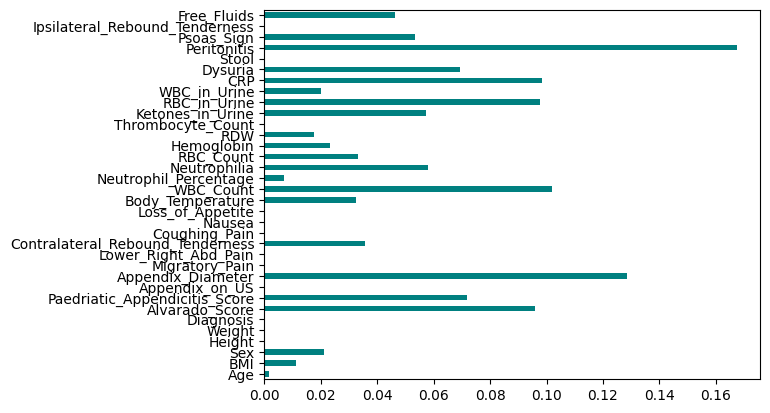

In [95]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(X,y,random_state=0)
feat_importance = pd.Series(importance, X.columns[0:len(X.columns)])
feat_importance.plot(kind='barh',color = 'teal')


mutual_info = pd.Series(importance)
mutual_info.index = X.columns
mutual_info.sort_values(ascending=False)


cols = mutual_info[mutual_info>0].index
cols
x_ig = X.loc[:,cols]

In [96]:
print("The shape of the reduced datset is(excluding the Diagnosis column)",x_ig.shape)

The shape of the reduced datset is(excluding the Diagnosis column) (157, 22)


In [97]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_ig.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0006 ± 0.0005
Score_time - Mean: 0.0146 ± 0.0010
Test_accuracy - Mean: 0.73 ± 0.06
Test_f1 - Mean: 0.37 ± 0.10
Test_roc_auc - Mean: 0.65 ± 0.08
Test_average_precision - Mean: 0.49 ± 0.09
Test_precision - Mean: 0.58 ± 0.21
Test_recall - Mean: 0.27 ± 0.07
AUPR: 0.52 ± 0.12
------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0289 ± 0.0104
Score_time - Mean: 0.0041 ± 0.0000
Test_accuracy - Mean: 0.83 ± 0.04
Test_f1 - Mean: 0.67 ± 0.07
Test_roc_auc - Mean: 0.84 ± 0.06
Test_average_precision - Mean: 0.78 ± 0.07
Test_precision - Mean: 0.77 ± 0.08
Test_recall - Mean: 0.60 ± 0.10
AUPR: 0.77 ± 0.08
------------------------------------------------------------------------------------------------------




Classifier: Gaus

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	34
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	34
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	34
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	34
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	34
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	34
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	34
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	3
Tentative: 	2
Rejected: 	29
Iteration: 	9 / 10
Confirmed: 	3
Tentative: 	2
Rejected: 	29


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	3
Tentative: 	1
Rejected: 	29

------Support and Ranking for each feature------
Doesn't pass the test:  Age  - Ranking:  14
Doesn't pass the test:  BMI  - Ranking:  7
Doesn't pass the test:  Sex  - Ranking:  27
Doesn't pass the test:  Height  - Ranking:  7
Doesn't pass the test:  Weight  - Ranking:  12
Doesn't pass the test:  Diagnosis  - Ranking:  31
Doesn't pass the test:  Alvarado_Sc

Index(['Peritonitis', 'Appendix_Diameter', 'WBC_Count',
       'Neutrophil_Percentage', 'Paedriatic_Appendicitis_Score',
       'Thrombocyte_Count', 'CRP', 'RDW', 'BMI', 'Height', 'Alvarado_Score',
       'Body_Temperature', 'RBC_Count', 'Weight', 'RBC_in_Urine', 'Age',
       'Nausea'],
      dtype='object')

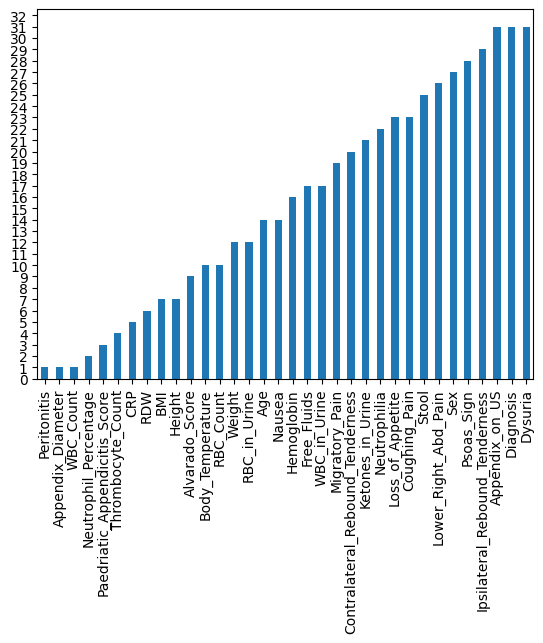

In [98]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(X,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(X), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])
        
        
        
sel_col = pd.Series(feat_selector.ranking_,index=X.columns)
sel_col.sort_values(inplace=True)



sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly



brt15 = sel_col[sel_col.values<16]
brt15.index

In [99]:
cols = brt15.index
X_brt = X.loc[:,cols]
print("The shape of the reduced dataset is (excluding the Diagnosis Column):",X_brt.shape)

The shape of the reduced dataset is (excluding the Diagnosis Column): (157, 17)


In [100]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X_brt.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0000 ± 0.0000
Score_time - Mean: 0.0143 ± 0.0011
Test_accuracy - Mean: 0.71 ± 0.07
Test_f1 - Mean: 0.28 ± 0.18
Test_roc_auc - Mean: 0.63 ± 0.07
Test_average_precision - Mean: 0.43 ± 0.08
Test_precision - Mean: 0.45 ± 0.28
Test_recall - Mean: 0.20 ± 0.13
AUPR: 0.41 ± 0.15


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0610 ± 0.0148
Score_time - Mean: 0.0042 ± 0.0004
Test_accuracy - Mean: 0.84 ± 0.07
Test_f1 - Mean: 0.71 ± 0.10
Test_roc_auc - Mean: 0.84 ± 0.04
Test_average_precision - Mean: 0.78 ± 0.08
Test_precision - Mean: 0.80 ± 0.15
Test_recall - Mean: 0.65 ± 0.12
AUPR: 0.77 ± 0.08
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0006 ± 0.0005
Score_time - Mean: 0.0041 ± 0.0000
Test_accuracy - Mean: 0.85 ± 0.06
Test_f1 - Mean: 0.70 ± 0.09
Test_roc_auc - Mean: 0.84 ± 0.05
Test_average_precision - Mean: 0.79 ± 0.05
Test_precision - Mean: 0.86 ± 0.15
Test_recall - Mean: 0.61 ± 0.12
AUPR: 0.78 ± 0.06
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

## Using SHAP value as a Feature Selection technique:

In [101]:
model = DT

In [102]:
# !pip install shap
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)

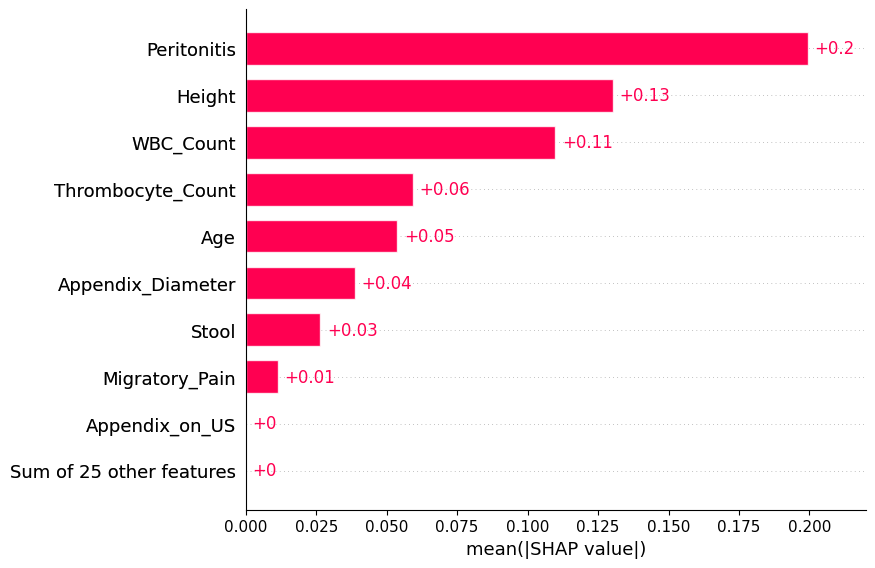

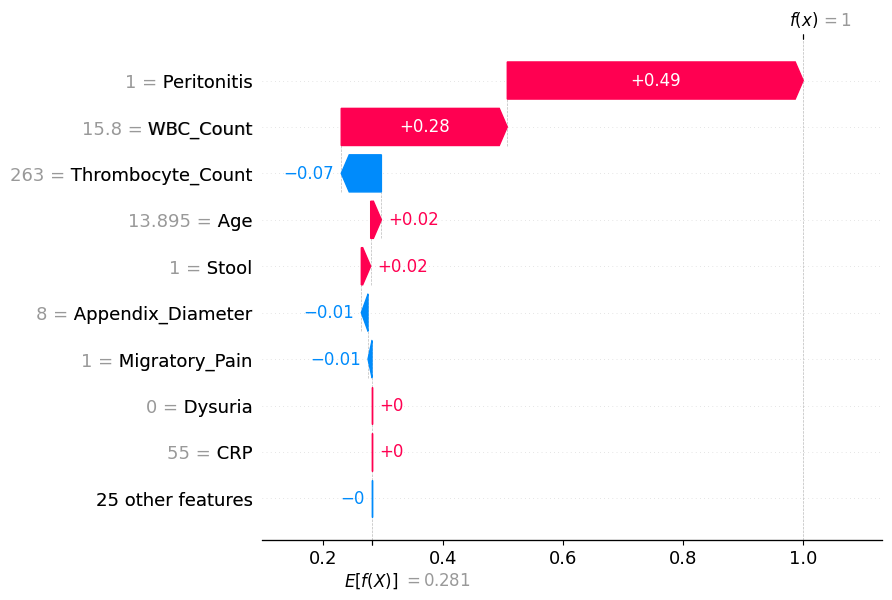

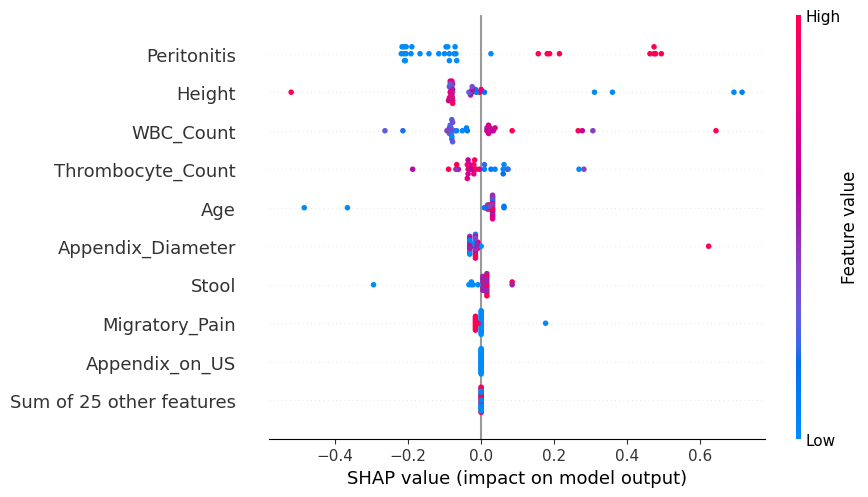

In [103]:
shap.plots.bar(shap_values)
shap.plots.waterfall(shap_values[0])
shap.plots.beeswarm(shap_values)

In [104]:
cols = ["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count"]

In [105]:
X_shap = X.loc[:,cols]
print("The shape of the reduced dataset is :",X_shap.shape)

The shape of the reduced dataset is : (157, 4)


In [106]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X_shap.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0004 ± 0.0005
Score_time - Mean: 0.0054 ± 0.0005
Test_accuracy - Mean: 0.64 ± 0.06
Test_f1 - Mean: 0.12 ± 0.10
Test_roc_auc - Mean: 0.58 ± 0.10
Test_average_precision - Mean: 0.35 ± 0.03
Test_precision - Mean: 0.17 ± 0.15
Test_recall - Mean: 0.09 ± 0.08
AUPR: 0.33 ± 0.07
------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0037 ± 0.0005
Score_time - Mean: 0.0040 ± 0.0001
Test_accuracy - Mean: 0.77 ± 0.06
Test_f1 - Mean: 0.54 ± 0.11
Test_roc_auc - Mean: 0.76 ± 0.07
Test_average_precision - Mean: 0.64 ± 0.10
Test_precision - Mean: 0.66 ± 0.15
Test_recall - Mean: 0.47 ± 0.10
AUPR: 0.61 ± 0.11
------------------------------------------------------------------------------------------------------




Classifier: Gaus

# Selecting the best reduced dataset and applying Ensemble Techniques:

In [107]:
# Boosting Classifiers
# random forest
RF = RandomForestClassifier(
    n_estimators=100,    # Number of trees in the forest
    criterion='gini',    # Split criterion ('gini' or 'entropy')
    max_depth=None,      # Maximum depth of the tree
    min_samples_split=2, # Minimum number of samples required to split an internal node
    min_samples_leaf=1,  # Minimum number of samples required to be at a leaf node
#     max_features='auto', # Number of features to consider when looking for the best split
    random_state=42,     # Random state for reproducibility
    n_jobs=-1            # Number of jobs to run in parallel (-1 means using all processors)
)

RF2 = RandomForestClassifier(
    n_estimators=200,    # Number of trees in the forest
    criterion='gini',    # Split criterion ('gini' or 'entropy')
    max_depth=None,      # Maximum depth of the tree
    min_samples_split=2, # Minimum number of samples required to split an internal node
    min_samples_leaf=1,  # Minimum number of samples required to be at a leaf node
#     max_features='auto', # Number of features to consider when looking for the best split
    random_state=42,     # Random state for reproducibility
    n_jobs=-1            # Number of jobs to run in parallel (-1 means using all processors)
)

# gradient boosting machine (GBM)
gbm_model = GradientBoostingClassifier(
    learning_rate=0.1,      # Learning rate or step size at which the model is updated. Typical values: [0.01, 0.05, 0.1].
    n_estimators=100,       # Number of boosting rounds (trees) to be used in the model. Typical values: [100, 200, 300].
    max_depth=6,            # Maximum depth of each tree. A higher value can lead to overfitting. Typical values: [3, 4, 5, 6].
    min_samples_split=2,    # Minimum number of samples required to split an internal node. Typical values: [2, 5, 10].
    min_samples_leaf=1,     # Minimum number of samples required to be at a leaf node. Typical values: [1, 2, 4].
    subsample=1.0,          # Subsample ratio of the training instance. Randomly selects a fraction of the data to grow trees. Typical values: [0.7, 0.8, 0.9].
    max_features=None,      # Number of features to consider when looking for the best split. Typical values: [None, 'sqrt', 'log2'].
    max_leaf_nodes=None,    # Maximum number of leaves in each tree. Typical values: [None, 10, 50, 100].
    random_state=42         # Seed for random number generator for reproducibility.
)


# light gradient boosting (lGBM)
LGBM = LGBMClassifier(verbose=-1)
    #learning_rate=0.1,      # Learning rate or step size at which the model is updated. Typical values: [0.01, 0.05, 0.1].
    #n_estimators=200,       # Number of boosting rounds (trees) to be used in the model. Typical values: [100, 200, 300].
    #max_depth=None,          # Maximum depth of each tree. A higher value can lead to overfitting. Typical values: [3, 4, 5, 6].
    #verbose=-1)


# xtreme gradient boosting (XGBoost)
XGB = XGBClassifier(objective='binary:logistic')

# categorical boosting (CatBoost)
CATBOOST = CatBoostClassifier(
    iterations=1000,          # Number of boosting iterations
    learning_rate=0.1,        # Learning rate for gradient boosting
    depth=6,                  # Depth of the trees
    loss_function='Logloss',  # Loss function to optimize
    eval_metric='Accuracy',   # Metric for evaluation
    random_seed=42)           # Random seed for reproducibility

# adaptive boosting (AdaBoost)
base_esti = LGBM # set to anything, tree based / normals / gbms

ADABOOST = AdaBoostClassifier(
    # base_estimator=base_esti,  # Base estimator to use for boosting
    n_estimators=200,               # Number of weak learners to train iteratively
    learning_rate=0.1,             # Learning rate (shrinks the contribution of each classifier)
    algorithm='SAMME',           # AdaBoost algorithm ('SAMME' or 'SAMME.R')
    random_state=42)               # Random state for reproducibility

ADABOOST2 = AdaBoostClassifier(
    estimator=base_esti,  # Base estimator to use for boosting
    n_estimators=200,               # Number of weak learners to train iteratively
    learning_rate=0.5,             # Learning rate (shrinks the contribution of each classifier)
    algorithm='SAMME',           # AdaBoost algorithm ('SAMME' or 'SAMME.R')
    random_state=42)    

In [109]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_ig.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [RF, LGBM,XGB, ADABOOST, ADABOOST2]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1395 ± 0.0095
Score_time - Mean: 0.0433 ± 0.0009
Test_accuracy - Mean: 0.82 ± 0.05
Test_f1 - Mean: 0.65 ± 0.05
Test_roc_auc - Mean: 0.86 ± 0.07
Test_average_precision - Mean: 0.84 ± 0.07
Test_precision - Mean: 0.81 ± 0.17
Test_recall - Mean: 0.56 ± 0.05
AUPR: 0.83 ± 0.07
------------------------------------------------------------------------------------------------------




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0102 ± 0.0000
Score_time - Mean: 0.0056 ± 0.0005
Test_accuracy - Mean: 0.80 ± 0.08
Test_f1 - Mean: 0.62 ± 0.09
Test_roc_auc - Mean: 0.84 ± 0.05
Test_average_precision - Mean: 0.78 ± 0.06
Test_precision - Mean: 0.77 ± 0.21
Test_recall - Mean: 0.55 ± 0.11
AUPR: 0.77 ± 0.06
------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)


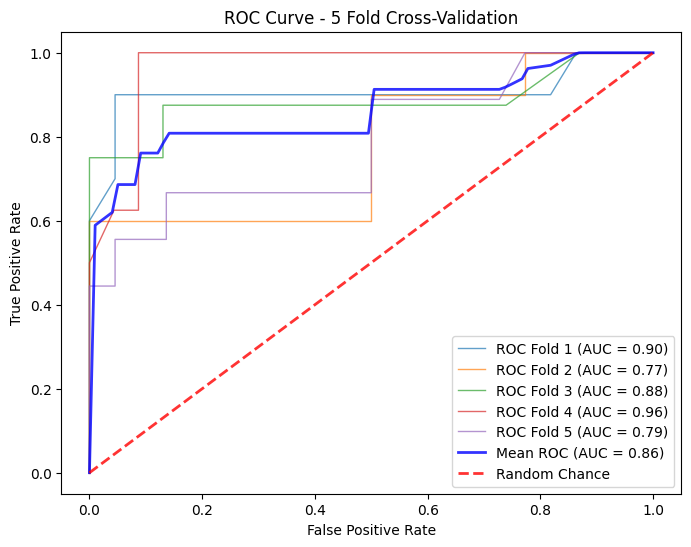

------------------------------------------------------------------------------------------------------




Classifier: LGBMClassifier(verbose=-1)


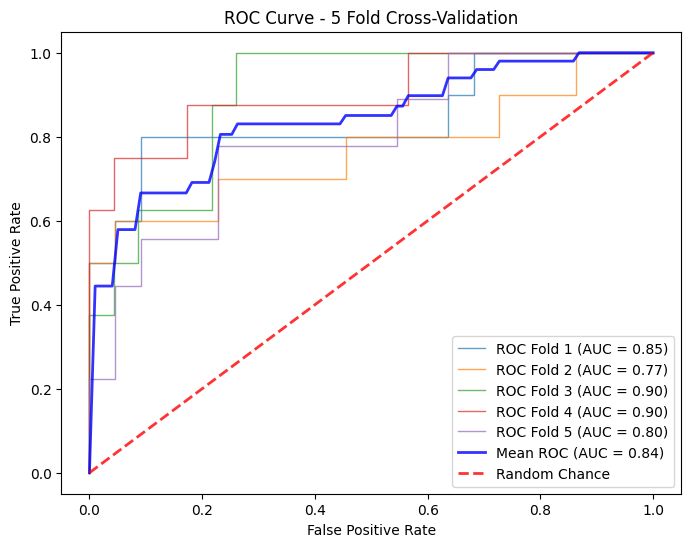

------------------------------------------------------------------------------------------------------




Classifier: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)


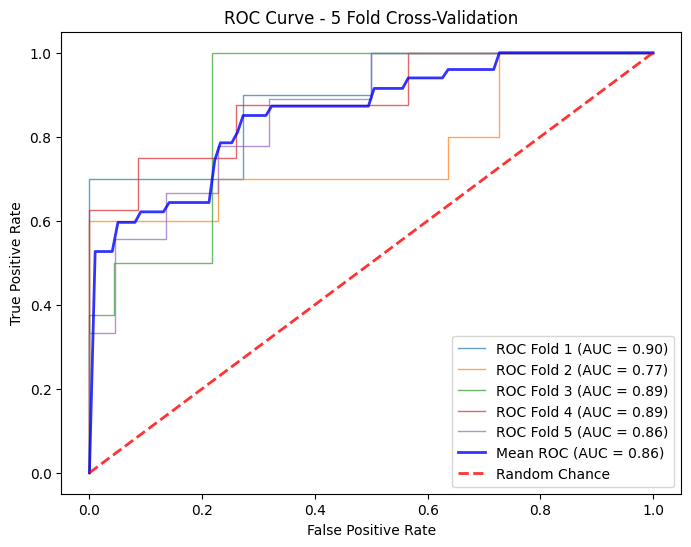

------------------------------------------------------------------------------------------------------




Classifier: AdaBoostClassifier(algorithm='SAMME', learning_rate=0.1, n_estimators=200,
                   random_state=42)


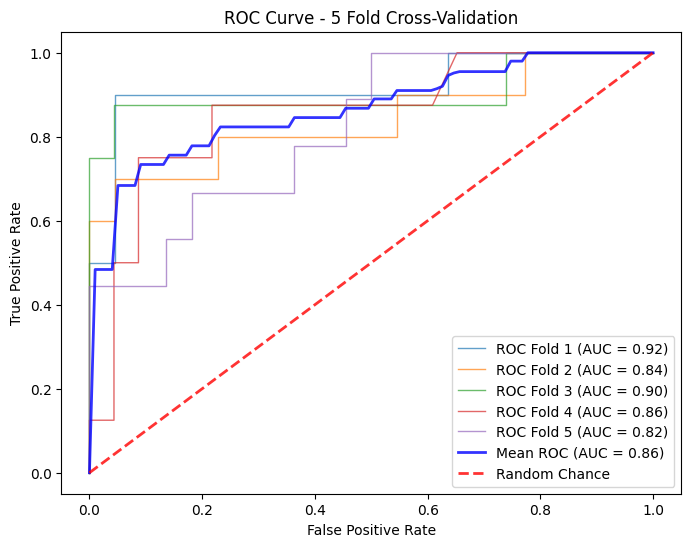

In [110]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

model_list = [RF, LGBM,XGB, ADABOOST]

for model in model_list:
    # Assuming you have your data and model ready
    X = x_ig
    # X= pd.concat([x_train,x_test])
    # y= pd.concat([y_train,y_test])
    # y = your_labels  # Target variable

    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    plt.figure(figsize=(8, 6))
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )
    # Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
    mean_tpr = 0.0
    mean_fpr = np.linspace(0, 1, 100)
    all_tpr = []

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, Y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Compute ROC curve and area under the curve
        fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve for this fold
        plt.plot(fpr, tpr, lw=1, alpha=0.7,
                 label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

        # Interpolate tpr at mean_fpr
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
        mean_tpr[0] = 0.0

    # Calculate mean of tprs and auc across all folds
    mean_tpr /= kf.get_n_splits(X)
    mean_auc = auc(mean_fpr, mean_tpr)

    # Plot mean ROC curve
    plt.plot(mean_fpr, mean_tpr, color='b',
             label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

    # Plot the random chance line
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
             label='Random Chance', alpha=.8)

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - 5 Fold Cross-Validation')
    plt.legend(loc='lower right')
    plt.show()


In [111]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X_brt.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [RF, LGBM,XGB, ADABOOST, ADABOOST2]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1145 ± 0.0049
Score_time - Mean: 0.0402 ± 0.0013
Test_accuracy - Mean: 0.82 ± 0.04
Test_f1 - Mean: 0.64 ± 0.03
Test_roc_auc - Mean: 0.87 ± 0.06
Test_average_precision - Mean: 0.84 ± 0.06
Test_precision - Mean: 0.79 ± 0.13
Test_recall - Mean: 0.56 ± 0.05
AUPR: 0.83 ± 0.07
------------------------------------------------------------------------------------------------------




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0098 ± 0.0005
Score_time - Mean: 0.0051 ± 0.0000
Test_accuracy - Mean: 0.82 ± 0.06
Test_f1 - Mean: 0.64 ± 0.09
Test_roc_auc - Mean: 0.88 ± 0.05
Test_average_precision - Mean: 0.82 ± 0.07
Test_precision - Mean: 0.84 ± 0.17
Test_recall - Mean: 0.57 ± 0.17
AUPR: 0.81 ± 0.07
------------------------------------------------------------------------------------------------------

In [113]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [RF, LGBM,XGB, ADABOOST, ADABOOST2]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1297 ± 0.0031
Score_time - Mean: 0.0454 ± 0.0051
Test_accuracy - Mean: 0.85 ± 0.05
Test_f1 - Mean: 0.71 ± 0.06
Test_roc_auc - Mean: 0.88 ± 0.09
Test_average_precision - Mean: 0.86 ± 0.08
Test_precision - Mean: 0.89 ± 0.16
Test_recall - Mean: 0.60 ± 0.03
AUPR: 0.86 ± 0.08
------------------------------------------------------------------------------------------------------




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.0093 ± 0.0004
Score_time - Mean: 0.0059 ± 0.0004
Test_accuracy - Mean: 0.80 ± 0.11
Test_f1 - Mean: 0.64 ± 0.14
Test_roc_auc - Mean: 0.86 ± 0.07
Test_average_precision - Mean: 0.81 ± 0.07
Test_precision - Mean: 0.77 ± 0.21
Test_recall - Mean: 0.57 ± 0.14
AUPR: 0.80 ± 0.07
------------------------------------------------------------------------------------------------------